<a href="https://colab.research.google.com/github/Samar97adel/Data-Analysis/blob/main/text_feedack_word_cloud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!gdown "16qwMeInEn56hHp-trzHzzDX7raTbj3Gx"

Downloading...
From: https://drive.google.com/uc?id=16qwMeInEn56hHp-trzHzzDX7raTbj3Gx
To: /content/text_feedback_for_wordcloud.csv
100% 100k/100k [00:00<00:00, 4.84MB/s]


In [ ]:
import pandas as pd

df = pd.read_csv('/content/text_feedback_for_wordcloud.csv')

In [ ]:
df.head()

,id,domain,sentiment,text
0,1,online_course_feedback,positive,I liked the real world examples and projects. ...
1,2,ecommerce_product_review,positive,This product works exactly as advertised. The ...
2,3,online_course_feedback,neutral,The course covered the basic topics as expecte...
3,4,online_course_feedback,positive,The platform was easy to navigate and use. The...
4,5,online_course_feedback,neutral,It was neither too advanced nor too simple. I ...


In [ ]:
df['sentiment'].value_counts()

,count
sentiment,
positive,399
negative,213
neutral,188


In [ ]:
df['domain'].value_counts()

,count
domain,
city_life_opinion,207
mobile_app_review,202
online_course_feedback,200
ecommerce_product_review,191


In [ ]:
STOPWORDS = {
    "the", "a", "an", "and", "or", "in", "on", "at", "for", "to", "of", "with",
    "is", "are", "was", "were", "be", "been", "it", "this", "that", "as", "by",
    "from", "i", "you", "he", "she", "we", "they", "them", "my", "your", "his", "her", "our",
    "their", "about", "very", "can", "could", "should", "would", "will", "just", "so",
    "but", "if", "not", "no", "yes", "do", "does", "did", "have", "has", "had",
    "there", "some", "any", "more", "most", "many", "few", "other", "also", "overall", "again", "others"
}

In [ ]:
import re

I liked the real world examples and projects. This was better than I initially expected.

In [ ]:
def clean_text(text):
  text = text.lower()

  text = re.sub(r'[^a-z\s]', ' ', text)

  words = text.split()

  cleaned_words = [ w.strip() for w in words if w not in STOPWORDS and len(w) > 2 ]

  return cleaned_words

In [ ]:
sample_text = df.loc[0, 'text']
cleaned_text = clean_text(sample_text)
print(sample_text)
print(cleaned_text)

I liked the real world examples and projects. This was better than I initially expected.
['liked', 'real', 'world', 'examples', 'projects', 'better', 'than', 'initially', 'expected']


In [ ]:
all_words = []

for text in df['text']:
  words = clean_text(text)
  all_words.extend(words)

len(all_words)

6134

In [ ]:
from wordcloud import WordCloud
from collections import Counter

In [ ]:
word_counts = Counter(all_words)

In [ ]:
word_counts.most_common(20)

[('use', 116),
 ('acceptable', 102),
 ('match', 102),
 ('while', 96),
 ('experience', 86),
 ('mostly', 86),
 ('positive', 86),
 ('minor', 86),
 ('issues', 86),
 ('opinion', 86),
 ('still', 86),
 ('improved', 86),
 ('expected', 84),
 ('sure', 84),
 ('choose', 84),
 ('fully', 84),
 ('reviews', 84),
 ('read', 84),
 ('online', 84),
 ('details', 83)]

In [ ]:
'mostly' in all_words

True

In [ ]:
all_text = ' '.join(all_words)



In [ ]:
all_text = re.sub(r'[^\w\s]', ' ', all_text)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_counts)

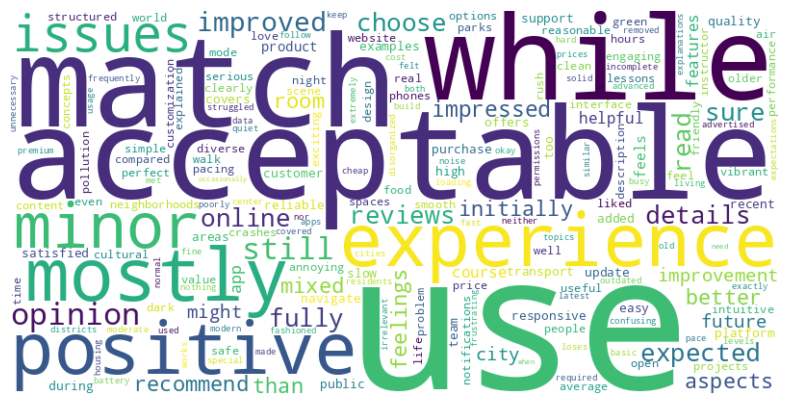

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [ ]:
def get_words_by_sentiment(df, sentiment):
  all_words = []
  subset = df[df['sentiment'] == sentiment]
  for text in subset['text']:
    words = clean_text(text)
    all_words.extend(words)

  word_counts = Counter(all_words)
  return word_counts

In [ ]:
positive_words = get_words_by_sentiment(df, 'positive')
negative_words = get_words_by_sentiment(df, 'negative')
neutral_words = get_words_by_sentiment(df, 'neutral')

In [ ]:
print(positive_words)
print(negative_words)
print(neutral_words)

Counter({'use': 67, 'helpful': 51, 'fully': 47, 'match': 47, 'reviews': 47, 'read': 47, 'online': 47, 'might': 44, 'future': 44, 'recommend': 42, 'sure': 41, 'choose': 41, 'better': 40, 'than': 40, 'initially': 40, 'expected': 40, 'opinion': 40, 'still': 40, 'improved': 40, 'city': 40, 'experience': 37, 'mostly': 37, 'positive': 37, 'minor': 37, 'issues': 37, 'details': 37, 'impressed': 37, 'while': 37, 'room': 36, 'improvement': 36, 'acceptable': 36, 'mixed': 35, 'feelings': 35, 'aspects': 35, 'feels': 35, 'customer': 28, 'support': 28, 'team': 28, 'responsive': 28, 'satisfied': 27, 'purchase': 27, 'public': 25, 'transport': 25, 'reliable': 25, 'covers': 25, 'areas': 25, 'platform': 23, 'easy': 23, 'navigate': 23, 'recent': 23, 'update': 23, 'added': 23, 'features': 23, 'safe': 21, 'walk': 21, 'night': 21, 'neighborhoods': 21, 'liked': 20, 'real': 20, 'world': 20, 'examples': 20, 'projects': 20, 'love': 20, 'dark': 20, 'mode': 20, 'customization': 20, 'options': 20, 'price': 20, 'reas

In [ ]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(positive_words)

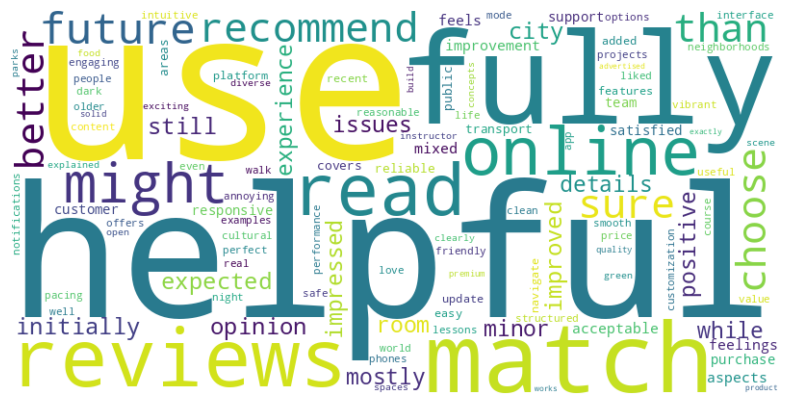

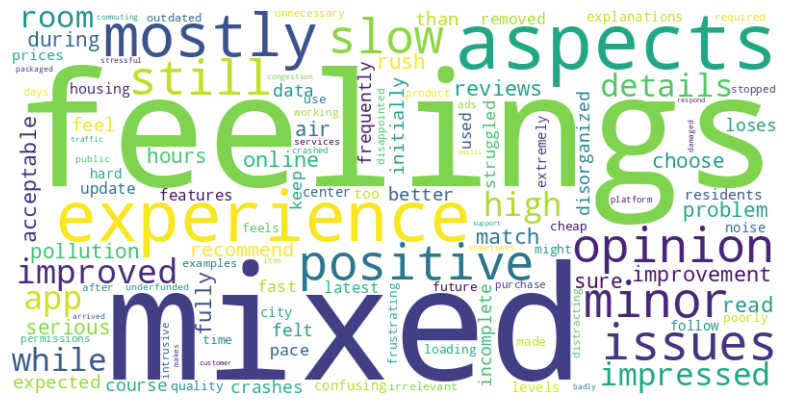

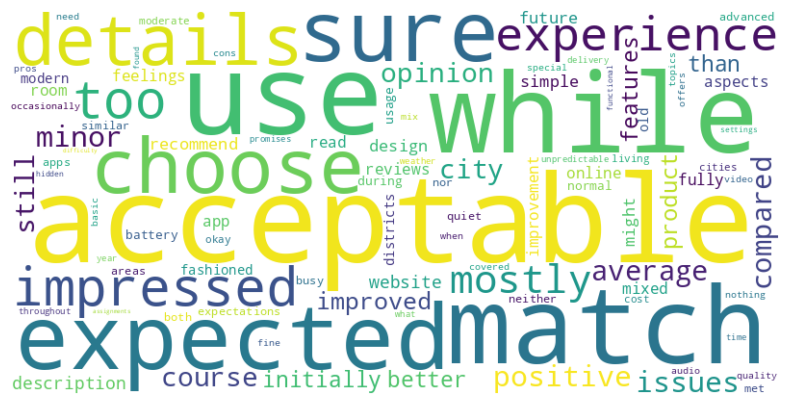

In [ ]:
for i in [positive_words, negative_words, neutral_words]:
  wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(i)
  plt.figure(figsize=(10, 5))
  plt.imshow(wordcloud, interpolation='bilinear')
  plt.axis('off')
  plt.show()